# The gene panel: two coupled networks tested for selection across primates

**Scope.** This notebook defines and justifies the gene panel for the primate sexual-dichromatism selection
scan, and it does so **reproducibly**: every gene list, evidence assignment, orthology flag, and count below is
*computed by the code in this notebook* from the project's raw source files — nothing is asserted from a
precomputed table. Re-running the notebook regenerates the panel from scratch.

We test two coupled molecular systems for signatures of selection: the **melanocyte pigmentation network** and
the **sex-hormone (hypothalamic-pituitary-gonadal) axis**. Sexual dichromatism is a pigmentation phenotype
expressed in a sex-limited way, so the a-priori design pairs the pigment machinery with the sex-steroid
signaling that could gate its expression. The two modules are matched in breadth so per-module comparisons
reflect biology, not sampling.

**Raw inputs — the evidence the panel is *derived from* (all version-controlled in this repository):**
- `comparative-genomics/analysis/data/pigmentation_network_nodes.csv` — the 803-node curated pigmentation
  network with per-gene evidence layers (OMIM pigmentation phenotype, Raghunath melanogenesis-mechanism token,
  melanosome mass-spec, functional CRISPR screen).
- `comparative-genomics/analysis/data/hormone_axes.csv` — hormone-module genes with endocrine-axis labels
  (seeded from KEGG hsa00140 + hsa04912 + design-added receptors/cofactors; see the provenance manifest).
- `data/processed/baxter2018_650_pigmentation_genes.csv` — Baxter et al. 2019 curated pigmentation reference

**Output this notebook motivates** (*not* a raw input):
- `comparative-genomics/config/gene_panel.csv` — the gene panel carried in the primate selection scan
  (27 pigmentation-core + 53 hormone). This is the *result* of the panel-justification logic below, not an
  evidence source. The notebook loads it only as the reference set, to show the derivation reproduces it and to
  measure module balance against it.
  (*Pigment Cell Melanoma Res* 32:348, doi:10.1111/pcmr.12743; 659 gene records, 635 unique human gene symbols).

## 0 — Input provenance

Every input below is a version-controlled file in this repository. Each traces to (a) the **notebook (or
pipeline) that produces it**, and (b) its ultimate external source, recorded in the repo-level manifest
`DATA_SOURCES.md` (with a per-source `docs/specs/*.spec.md` where applicable). The manifest is encoded as the
`INPUTS` dict in the next cell, so provenance is *executable*: the loader prints, for each file, the source
notebook, the external source, and a SHA256 checksum of the exact bytes read. Nothing here is read from a
precomputed summary table — the panel is rebuilt from these raw files below.

| Evidence input | Source notebook / pipeline | External source (DATA_SOURCES.md) |
|---|---|---|
| `analysis/data/pigmentation_network_nodes.csv` | **NB07** `07_harmonized_substrate.ipynb` — byte-identical frozen copy of its `data/processed/nb7_substrate_nodes.csv` | Entries 5 (Raghunath 2015), 2 (Bajpai 2023 CRISPR), 6/7 (OMIM/MGI/ZFIN/GO, D'Arcy 2023 STRING+mass-spec), 6c (KEGG hsa04916); spec `docs/specs/nb7_substrate.spec.md` |
| `analysis/data/hormone_axes.csv` | **NB13** `13_sex_hormone_layer.ipynb` — assembled there | Entry 12: **KEGG hsa00140** (steroid hormone biosynthesis, 27 genes) + **KEGG hsa04912** (GnRH signaling, 8 genes) + design-added AR/ESR1/2/GPER1/FSHR/LHCGR receptors and cofactors/carriers (NCOA1/2/3, NCOR1/2, SHBG, FKBP5, SCARB1, LDLR, STAR, KISS1/1R); axis-annotated |
| `data/processed/baxter2018_650_pigmentation_genes.csv` | **NB01b** `01b_extract_baxter_genes.ipynb` — extracts Baxter Table S7 | Entry 3 + `docs/specs/baxter2018.spec.md` (Baxter et al. 2019, doi:10.1111/pcmr.12743, 635 unique human symbols); raw `.xlsx` git-ignored, re-obtain via DOI |

**Output (motivated, not ingested):** `config/gene_panel.csv` is the scan panel this notebook justifies — a `set`-labeled concatenation of the 53-gene hormone module (= `hormone_axes.csv` verbatim) and the 27 pigmentation-core genes (canonical melanogenesis core drawn from the NB07 network; 24/27 also in Baxter 2019; anchored on the Nadeau-2007 loci MC1R/TYR/TYRP1/DCT/ASIP/POMC). It is loaded below as `SCAN_PANEL` — the reference the derivation reproduces — not as an evidence source.

In [ ]:
import os, json, time, hashlib
import pandas as pd, requests
REPO = os.environ.get("PIGNET_REPO", os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
CG   = os.path.join(REPO, "comparative-genomics")

# --- Provenance manifest: every raw input, where it comes from, and how to regenerate it. ---
# (mirrors the repo-level DATA_SOURCES.md; keep in sync if a source changes)
INPUTS = {
    "network_nodes": {
        "path": "comparative-genomics/analysis/data/pigmentation_network_nodes.csv",
        "notebook": "NB07 (07_harmonized_substrate.ipynb) — byte-identical frozen copy of nb7_substrate_nodes.csv",
        "what": "803-node curated pigmentation network with per-gene evidence layers "
                "(supporting_layers, omim_phenotype_class, massspec_detected_flag, bajpai_hit_flag)",
        "source": "DATA_SOURCES.md entries 5 (Raghunath 2015), 2 (Bajpai 2023 CRISPR), "
                  "6/7 (OMIM/MGI/ZFIN/GO + D'Arcy 2023 STRING/mass-spec), 6c (KEGG hsa04916)",
        "produced_by": "Notebooks 1-7 (network assembly); this notebook only reads it",
    },
    "hormone_axes": {
        "path": "comparative-genomics/analysis/data/hormone_axes.csv",
        "notebook": "NB13 (13_sex_hormone_layer.ipynb) — KEGG pathway pull + design-added receptors/cofactors",
        "what": "53 sex-hormone genes labeled by endocrine axis (steroid biosynthesis, HPG, "
                "androgen/estrogen receptor, GnRH, coactivators)",
        "source": "Seeded from KEGG steroid hormone biosynthesis (hsa00140, 27 genes) + KEGG GnRH signaling (hsa04912, 8 genes), plus androgen/estrogen receptor->target genes (AR, ESR1/2, GPER1, FSHR, LHCGR) and steroid-signaling cofactors/carriers (NCOA1/2/3, NCOR1/2, SHBG, FKBP5, SCARB1, LDLR, STAR, KISS1/1R) added per design; then axis-annotated",
        "produced_by": "Notebook 13 (sex-hormone layer)",
    },
    "baxter": {
        "path": "data/processed/baxter2018_650_pigmentation_genes.csv",
        "notebook": "NB01b (01b_extract_baxter_genes.ipynb) — extracts Baxter Table S7",
        "what": "Baxter 2019 curated cross-species pigmentation reference (Table S7; 635 unique human symbols)",
        "source": "DATA_SOURCES.md entry 3 + docs/specs/baxter2018.spec.md "
                  "(Baxter et al. 2019, Pigment Cell Melanoma Res 32:348, doi:10.1111/pcmr.12743)",
        "produced_by": "derived CSV from author-supplied Table S7; raw .xlsx git-ignored, re-obtain via DOI",
    },
}

def load_input(key):
    """Load a manifest input, printing its provenance and a checksum of the exact bytes read."""
    m = INPUTS[key]; fp = os.path.join(REPO, m["path"])
    raw = open(fp, "rb").read()
    sha = hashlib.sha256(raw).hexdigest()[:16]
    df = pd.read_csv(fp)
    print(f"[{key}] {m['path']}")
    print(f"    notebook : {m['notebook']}")
    print(f"    what     : {m['what']}")
    print(f"    source   : {m['source']}")
    print(f"    produced : {m['produced_by']}")
    print(f"    loaded   : {df.shape[0]} rows x {df.shape[1]} cols | sha256[:16]={sha}\n")
    return df

NET = load_input("network_nodes")
HAX = load_input("hormone_axes")
BAX = load_input("baxter")
BAX_GENES = set(BAX["Human gene symbol"].dropna().astype(str).str.strip())

# --- The panel this notebook MOTIVATES (output/reference, not a raw evidence input). ---
# Loaded only to (a) find network genes not yet in the scan and (b) measure module balance.
SCAN_PANEL_PATH = "comparative-genomics/config/gene_panel.csv"
SCAN_PANEL = pd.read_csv(os.path.join(REPO, SCAN_PANEL_PATH))
_sha = hashlib.sha256(open(os.path.join(REPO, SCAN_PANEL_PATH), "rb").read()).hexdigest()[:16]
IN_PANEL = set(SCAN_PANEL.gene)
print(f"[SCAN_PANEL — output this notebook justifies] {SCAN_PANEL_PATH}")
print(f"    composite: hormone set == hormone_axes.csv (KEGG-seeded); pigmentation set = 27 melanogenesis-core (NB07 network + Nadeau anchor)")
print(f"    loaded   : {SCAN_PANEL.shape[0]} genes ({(SCAN_PANEL.set=='pigmentation').sum()} pigmentation + {(SCAN_PANEL.set=='hormone').sum()} hormone) | sha256[:16]={_sha}\n")
print(f"network nodes: {len(NET)} | genes already in scan panel: {len(IN_PANEL)} | Baxter reference: {len(BAX_GENES)}")

[network_nodes] comparative-genomics/analysis/data/pigmentation_network_nodes.csv
    notebook : NB07 (07_harmonized_substrate.ipynb) — byte-identical frozen copy of nb7_substrate_nodes.csv
    what     : 803-node curated pigmentation network with per-gene evidence layers (supporting_layers, omim_phenotype_class, massspec_detected_flag, bajpai_hit_flag)
    source   : DATA_SOURCES.md entries 5 (Raghunath 2015), 2 (Bajpai 2023 CRISPR), 6/7 (OMIM/MGI/ZFIN/GO + D'Arcy 2023 STRING/mass-spec), 6c (KEGG hsa04916)
    produced : Notebooks 1-7 (network assembly); this notebook only reads it
    loaded   : 803 rows x 17 cols | sha256[:16]=4053c652a8d4f832

[hormone_axes] comparative-genomics/analysis/data/hormone_axes.csv
    notebook : NB13 (13_sex_hormone_layer.ipynb) — KEGG pathway pull + design-added receptors/cofactors
    what     : 53 sex-hormone genes labeled by endocrine axis (steroid biosynthesis, HPG, androgen/estrogen receptor, GnRH, coactivators)
    source   : Seeded from KEGG ste

## 1 — Evidence flags, computed from the network layers

For every network gene we derive four pigmentation-specific evidence flags directly from the source columns.
These are the only evidence types we accept as "this is a pigmentation gene"; membership via generic
STRING/KEGG proximity alone does not qualify.

In [ ]:
NET["has_raghunath"] = NET.supporting_layers.astype(str).str.contains("Raghunath")   # melanogenesis mechanism
NET["omim_pigment"]  = NET.omim_phenotype_class.notna()                               # OMIM pigment disorder
NET["in_baxter"]     = NET.gene.isin(BAX_GENES)                                       # Baxter 2019 reference
NET["crispr_screen"] = NET.bajpai_hit_flag == True                                    # functional screen hit
NET["pig_specific"]  = NET.omim_pigment | NET.in_baxter | NET.crispr_screen
print("network genes with each evidence flag:")
for c in ["has_raghunath","omim_pigment","in_baxter","crispr_screen","pig_specific"]:
    print(f"  {c:14s}: {int(NET[c].sum())}")

network genes with each evidence flag:
  has_raghunath : 168
  omim_pigment  : 239
  in_baxter     : 204
  crispr_screen : 29
  pig_specific  : 310


**Figure — evidence flags.** Genes qualify as pigmentation-specific through any of four curated evidence types; the union (`pig_specific`) is the pool the expansion draws from.

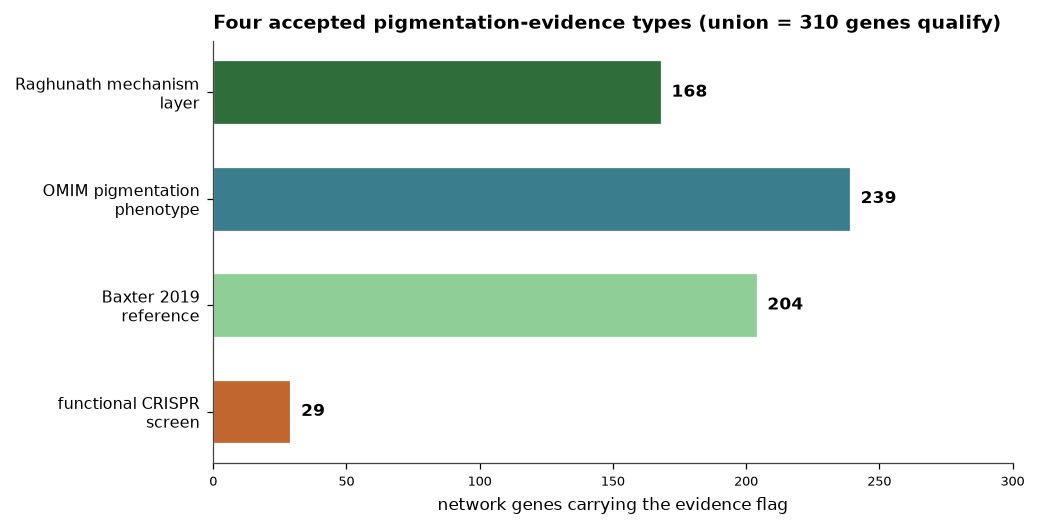

In [ ]:
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({"font.size":9,"axes.titlesize":10,"axes.titleweight":"bold","svg.fonttype":"none","figure.dpi":150,"axes.edgecolor":"#444"})
os.makedirs("figures", exist_ok=True)
ev = [("Raghunath mechanism\nlayer", int(NET.has_raghunath.sum()), "#2f6d3a"),
      ("OMIM pigmentation\nphenotype", int(NET.omim_pigment.sum()), "#3a7d8c"),
      ("Baxter 2019\nreference", int(NET.in_baxter.sum()), "#8fce97"),
      ("functional CRISPR\nscreen", int(NET.crispr_screen.sum()), "#c0662e")]
union = int(NET.pig_specific.sum())
fig, ax = plt.subplots(figsize=(7,3.6))
for i,(n,v,col) in enumerate(ev):
    ax.barh(len(ev)-1-i, v, color=col, edgecolor="white", height=0.6)
    ax.text(v+4, len(ev)-1-i, str(v), va="center", fontsize=8, fontweight="bold")
ax.set_yticks(range(len(ev))[::-1]); ax.set_yticklabels([n for n,_,_ in ev], fontsize=7.5)
ax.set_xlim(0,300); ax.set_xlabel("network genes carrying the evidence flag")
ax.set_title(f"Four accepted pigmentation-evidence types (union = {union} genes qualify)", loc="left", fontsize=9)
for s in ["top","right"]: ax.spines[s].set_visible(False)
fig.tight_layout(); fig.savefig("figures/nb14_evidence_flags.png",dpi=150,bbox_inches="tight"); plt.show()


## 2 — Assemble the pigmentation expansion candidates from the layers

The original pigmentation module (27 genes) covered only melanin *synthesis* and its immediate regulators. Two
functional groups are demonstrably missing, and both are recovered here **by rule** from the network layers:

- **Melanosome biogenesis & transport** — genes with an OMIM pigmentation phenotype belonging to the
  melanosome-biogenesis/transport families (Hermansky-Pudlak, AP-3, BLOC-1, Griscelli RAB27A/MYO5A/MLPH, LYST,
  GPR143, the vitiligo SLC transporters). Selected by OMIM-pigment flag + gene-family name pattern.
- **Melanogenesis regulation** — genes on the Raghunath melanogenesis-mechanism layer that also carry
  pigmentation-specific evidence (OMIM pigment / Baxter / functional screen).

In [ ]:
cand = NET[~NET.gene.isin(IN_PANEL)].copy()

MEL_FAMILIES = ("HPS","AP3","BLOC","RAB27","MYO5","MLPH","LYST","GPR143",
                "RAB5C","SLC17A5","SLC1A2","SLC44A4","SLC29A3","CTNS")
def in_melanosome_family(g):
    return any(g.startswith(k) or k in g for k in MEL_FAMILIES)

group_A = cand[cand.omim_pigment & cand.gene.map(in_melanosome_family)].gene.tolist()
group_B = cand[cand.has_raghunath & cand.pig_specific].gene.tolist()
group_B = [g for g in group_B if g not in group_A]   # keep groups disjoint
print(f"Group A — melanosome biogenesis & transport: {len(group_A)}")
print("  ", ", ".join(sorted(group_A)))
print(f"Group B — melanogenesis regulation: {len(group_B)}")
print("  ", ", ".join(sorted(group_B)))
candidates = sorted(set(group_A) | set(group_B))
print(f"total expansion candidates: {len(candidates)}")

Group A — melanosome biogenesis & transport: 21
   AP3B1, AP3D1, BLOC1S3, BLOC1S5, BLOC1S6, CTNS, GPR143, HPS1, HPS3, HPS4, HPS5, HPS6, LYST, MLPH, MYO5A, RAB27A, RAB5C, SLC17A5, SLC1A2, SLC29A3, SLC44A4
Group B — melanogenesis regulation: 22
   BCL2, CDC42, CDH2, CTNNB1, EDN1, EGFR, EP300, FASLG, HGF, HRAS, MAP2K1, MAP2K2, MAPK3, PAK1, PPP3CA, RAC1, RACK1, RAF1, SPTLC2, SRC, TP53, TRAF6
total expansion candidates: 43


## 3 — Orthology screen against Ensembl Compara

A dN/dS scan is trustworthy only if each gene has a clean **one-to-one ortholog** in every primate genome. Two
failure modes threaten that: **paralog mis-mapping** (the ortholog-extraction step lands on a close paralog —
a risk for large gene families) and **incomplete ortholog coverage** (short/poorly-annotated genes missing from
scaffold-level or deep-lineage assemblies). We query the Ensembl REST homology endpoint for each candidate:
count how many of 12 reference primates carry a called ortholog, and how many human within-species paralogs
exist. The live query function is below; results are cached to `data/nb14_ensembl_orthology.json` so the
notebook re-runs deterministically and offline (delete the cache to force a fresh query).

In [ ]:
PRIMATES = ["pan_troglodytes","gorilla_gorilla","pongo_abelii","macaca_mulatta","macaca_fascicularis",
            "chlorocebus_sabaeus","papio_anubis","nomascus_leucogenys","callithrix_jacchus",
            "microcebus_murinus","otolemur_garnettii","carlito_syrichta"]
CACHE = os.path.join(CG, "analysis/module_selection/data/nb14_ensembl_orthology.json")

def ensembl_orthology(symbol, session, base="https://rest.ensembl.org"):
    """Return (n_primate_orthologs, n_human_paralogs) for a human gene symbol via Ensembl Compara."""
    hdr = {"Content-Type": "application/json"}
    r = session.get(f"{base}/lookup/symbol/homo_sapiens/{symbol}", headers=hdr, timeout=30)
    if r.status_code != 200:
        return None
    gid = r.json()["id"]
    h = session.get(f"{base}/homology/id/homo_sapiens/{gid}",
                    headers=hdr, params={"type": "all", "format": "condensed"}, timeout=60)
    if h.status_code != 200 or not h.json().get("data"):
        return (0, 0)
    homs = h.json()["data"][0]["homologies"]
    prim = {x["species"] for x in homs
            if x.get("type","").startswith("ortholog") and x.get("species") in PRIMATES}
    par  = sum(1 for x in homs
               if x.get("type") == "within_species_paralog" and x.get("species") == "homo_sapiens")
    return (len(prim), par)

if os.path.exists(CACHE):
    ortho = json.load(open(CACHE))
    print(f"loaded cached Ensembl orthology for {len(ortho)} genes (delete {os.path.basename(CACHE)} to refresh)")
else:
    print("querying Ensembl Compara (live)...")
    S = requests.Session(); ortho = {}
    for g in candidates:
        res = ensembl_orthology(g, S)
        ortho[g] = {"n_primate_orth": res[0], "n_within_paralog": res[1]} if res else {"n_primate_orth": 0, "n_within_paralog": 0}
        time.sleep(0.06)
    json.dump(ortho, open(CACHE, "w"), indent=1)
    print(f"queried {len(ortho)} genes; cached to {os.path.basename(CACHE)}")

loaded cached Ensembl orthology for 43 genes (delete nb14_ensembl_orthology.json to refresh)


## 4 — Derive the orthology risk flag, from the query results

A gene passes (`clean`) only with full paralog cleanliness and near-complete coverage. Flags: `HIGH_paralog`
(≥3 human paralogs), `paralog_check` (1–2 paralogs), `low_ortholog_cov` (<10/12 primates).

In [ ]:
def risk_flag(n_orth, n_par):
    f = []
    if   n_par >= 3: f.append("HIGH_paralog")
    elif n_par >= 1: f.append("paralog_check")
    if n_orth < 10:  f.append("low_ortholog_cov")
    return ";".join(f) if f else "clean"

orA = pd.DataFrame([{"gene": g, "group": ("melanosome_biogenesis" if g in group_A else "melanogenesis_regulation"),
                     "n_primate_orth": ortho[g]["n_primate_orth"], "n_within_paralog": ortho[g]["n_within_paralog"]}
                    for g in candidates])
orA["ortholog_risk"] = [risk_flag(r.n_primate_orth, r.n_within_paralog) for r in orA.itertuples()]
clean = orA[orA.ortholog_risk == "clean"]
print(f"orthology outcome: {len(clean)} clean / {len(orA)} candidates")
print("\nEXCLUDED (flagged):")
print(orA[orA.ortholog_risk != "clean"].sort_values("group").to_string(index=False))
print(f"\nCLEAN expansion ({len(clean)}): {(clean.group=='melanosome_biogenesis').sum()} melanosome + "
      f"{(clean.group=='melanogenesis_regulation').sum()} regulation")

orthology outcome: 30 clean / 43 candidates

EXCLUDED (flagged):
   gene                    group  n_primate_orth  n_within_paralog                  ortholog_risk
   BCL2 melanogenesis_regulation              11                 2                  paralog_check
   EDN1 melanogenesis_regulation              12                 2                  paralog_check
  FASLG melanogenesis_regulation              12                 7                   HIGH_paralog
 MAP2K1 melanogenesis_regulation              12                 1                  paralog_check
 MAP2K2 melanogenesis_regulation              12                 1                  paralog_check
   PAK1 melanogenesis_regulation              11                 2                  paralog_check
   RAC1 melanogenesis_regulation               8                 1 paralog_check;low_ortholog_cov
   TP53 melanogenesis_regulation              12                 2                  paralog_check
BLOC1S3    melanosome_biogenesis               7     

**Figure — orthology screen.** Each candidate is placed by ortholog coverage (x) and human paralog count (y); only genes in the clean quadrant enter the panel. Excluded genes are listed with their specific failure mode.

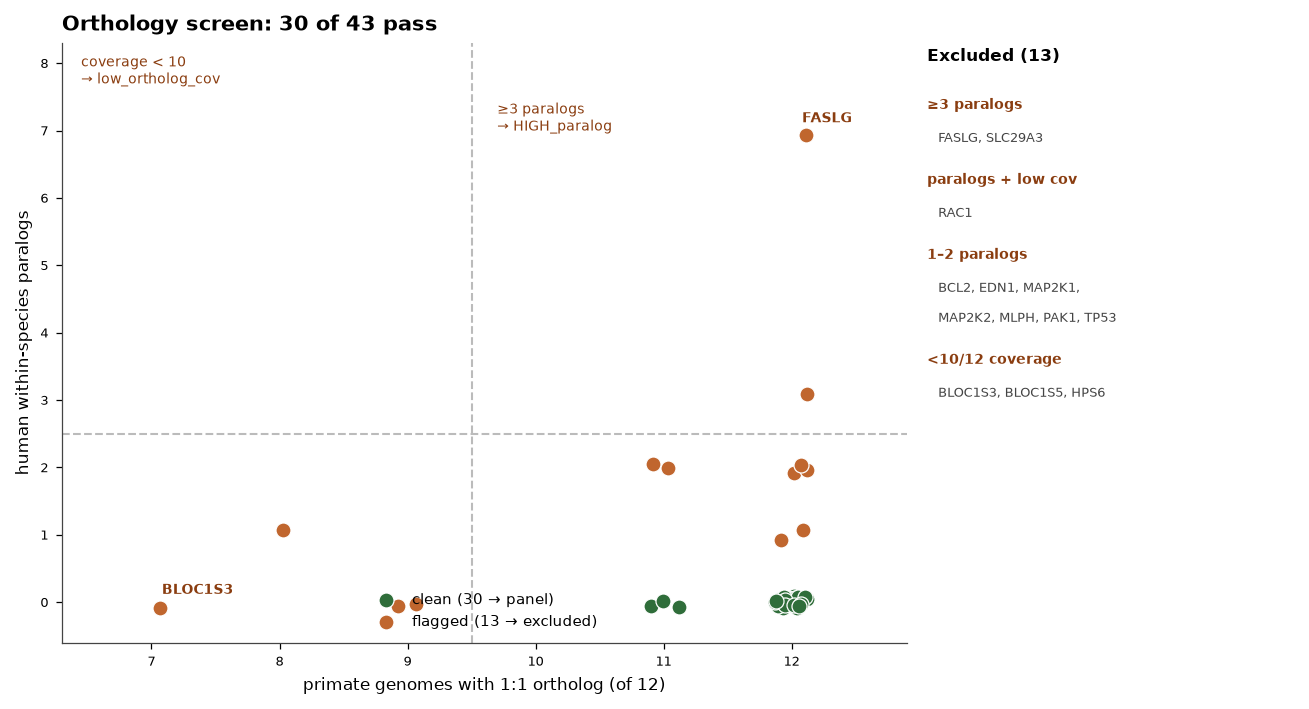

In [ ]:
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({"font.size":9,"axes.titlesize":10,"axes.titleweight":"bold","svg.fonttype":"none","figure.dpi":150,"axes.edgecolor":"#444"})
os.makedirs("figures", exist_ok=True)
import textwrap
_c = orA.copy(); _c["clean"] = _c.ortholog_risk.eq("clean")
fig,(ax,axT)=plt.subplots(1,2,figsize=(8.8,4.8),gridspec_kw={"width_ratios":[2.3,1]})
ax.axvline(9.5,color="#bbb",ls="--",lw=1); ax.axhline(2.5,color="#bbb",ls="--",lw=1)
ax.text(6.45,7.7,"coverage < 10\n\u2192 low_ortholog_cov",ha="left",fontsize=6.6,color="#8a3d10")
ax.text(9.7,7.0,"\u22653 paralogs\n\u2192 HIGH_paralog",ha="left",fontsize=6.6,color="#8a3d10")
rng=np.random.default_rng(3)
for cl,col,lab in [(True,"#2f6d3a",f"clean ({int(_c.clean.sum())} \u2192 panel)"),(False,"#c0662e",f"flagged ({int((~_c.clean).sum())} \u2192 excluded)")]:
    sub=_c[_c.clean==cl]
    jx=sub.n_primate_orth+rng.uniform(-0.13,0.13,len(sub)); jy=sub.n_within_paralog+rng.uniform(-0.10,0.10,len(sub))
    ax.scatter(jx,jy,s=52,color=col,edgecolor="white",lw=0.6,label=lab,zorder=3)
for r0 in [_c.loc[_c.n_within_paralog.idxmax()], _c.loc[_c.n_primate_orth.idxmin()]]:
    ax.annotate(r0.gene,(r0.n_primate_orth,r0.n_within_paralog),fontsize=6.6,fontweight="bold",xytext=(5,4),textcoords="offset points",color="#8a3d10")
ax.set_xlabel("primate genomes with 1:1 ortholog (of 12)"); ax.set_ylabel("human within-species paralogs")
ax.set_xlim(6.3,12.9); ax.set_ylim(-0.6,8.3); ax.set_title(f"Orthology screen: {int(_c.clean.sum())} of {len(_c)} pass", loc="left")
ax.legend(frameon=False, loc="lower center", fontsize=7, bbox_to_anchor=(0.5,0.0))
for s in ["top","right"]: ax.spines[s].set_visible(False)
axT.axis("off"); y=0.97; axT.text(0,y,f"Excluded ({int((~_c.clean).sum())})",fontsize=8,fontweight="bold",transform=axT.transAxes); y-=0.08
_pretty={"HIGH_paralog":"\u22653 paralogs","paralog_check":"1\u20132 paralogs","low_ortholog_cov":"<10/12 coverage","paralog_check;low_ortholog_cov":"paralogs + low cov"}
for reason in ["HIGH_paralog","paralog_check;low_ortholog_cov","paralog_check","low_ortholog_cov"]:
    genes=sorted(_c[_c.ortholog_risk==reason].gene)
    if not genes: continue
    axT.text(0,y,_pretty[reason],fontsize=6.8,color="#8a3d10",fontweight="bold",transform=axT.transAxes); y-=0.055
    for w in textwrap.wrap(", ".join(genes),26): axT.text(0.03,y,w,fontsize=6.3,color="#444",transform=axT.transAxes); y-=0.05
    y-=0.02
fig.tight_layout(); fig.savefig("figures/nb14_orthology_screen.png",dpi=150,bbox_inches="tight"); plt.show()


## 5 — The analytic panel

The panel = the 53-gene hormone axis + the original 27 pigmentation genes + the orthology-clean pigmentation
additions. The two modules are matched in breadth.

In [ ]:
n_hor   = (SCAN_PANEL.set == "hormone").sum()
n_pig0  = (SCAN_PANEL.set == "pigmentation").sum()
n_pig   = n_pig0 + len(clean)
balance = 2*n_pig/(n_pig+n_hor) - 1
print(f"sex-hormone module:  {n_hor} genes")
print(f"pigmentation module: {n_pig0} (original) + {len(clean)} (clean additions) = {n_pig}")
print(f"analytic panel total: {n_pig + n_hor} genes")
print(f"module balance-neutral point: {balance:+.3f}   (0 = perfectly balanced panel)")

sex-hormone module:  53 genes
pigmentation module: 27 (original) + 30 (clean additions) = 57
analytic panel total: 110 genes
module balance-neutral point: +0.036   (0 = perfectly balanced panel)


**Figure — panel balance.** The expansion moves the panel from hormone-heavy (−0.33) toward even: the two modules are matched in gene count, so a per-module selection comparison is not confounded by panel size.

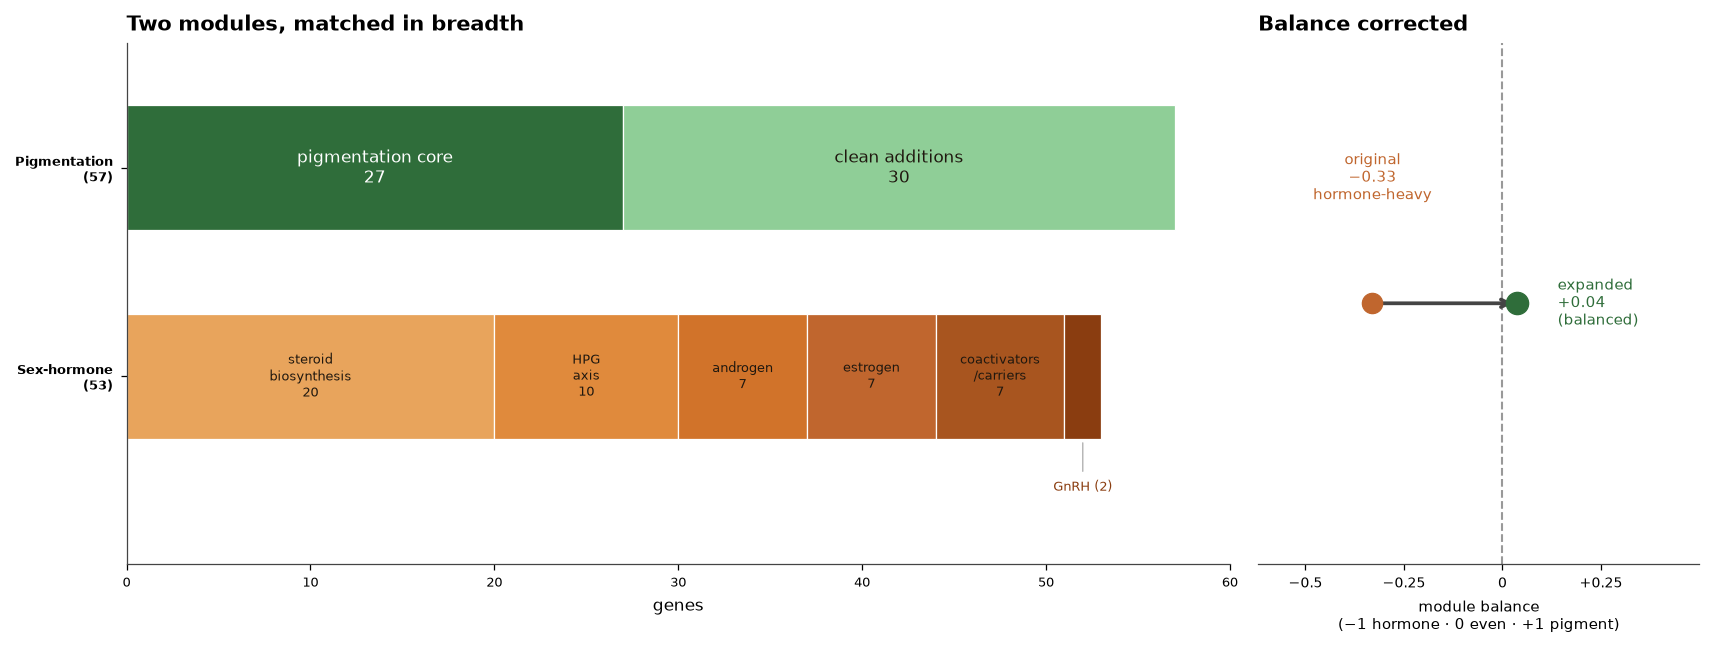

In [ ]:
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({"font.size":9,"axes.titlesize":10,"axes.titleweight":"bold","svg.fonttype":"none","figure.dpi":150,"axes.edgecolor":"#444"})
os.makedirs("figures", exist_ok=True)
hor_by_axis = HAX.axis_category.value_counts().sort_values(ascending=False)
oranges = ["#e8a45c","#e08a3c","#d1732a","#c0662e","#a8551f","#8a3d10"]
label_map = {"steroid_biosynthesis":"steroid\nbiosynthesis","hpg_axis":"HPG\naxis","androgen_axis":"androgen",
             "estrogen_axis":"estrogen","coactivator_corepressor_carrier":"coactivators\n/carriers","gnrh_signaling":"GnRH"}
fig, (axL, axR) = plt.subplots(1,2, figsize=(11.5,4.4), gridspec_kw={"width_ratios":[2.5,1]})
left=0
for name,c,col,tc in [("pigmentation core",n_pig0,"#2f6d3a","white"),("clean additions",n_pig-n_pig0,"#8fce97","#20180f")]:
    axL.barh(1.0,c,left=left,color=col,edgecolor="white",height=0.6); axL.text(left+c/2,1.0,f"{name}\n{c}",ha="center",va="center",fontsize=8,color=tc); left+=c
left=0
for i,(ax_cat,c) in enumerate(hor_by_axis.items()):
    col=oranges[i%len(oranges)]; axL.barh(0.0,c,left=left,color=col,edgecolor="white",height=0.6)
    lbl=label_map.get(ax_cat,ax_cat.replace("_"," "))
    if c>=7: axL.text(left+c/2,0.0,f"{lbl}\n{c}",ha="center",va="center",fontsize=6.4,color="#20180f")
    else: axL.annotate(f"GnRH ({c})",xy=(left+c/2,-0.30),xytext=(left+c/2,-0.55),ha="center",fontsize=6,color="#8a3d10",arrowprops=dict(arrowstyle="-",color="#aaa",lw=0.6))
    left+=c
axL.set_yticks([0,1]); axL.set_yticklabels([f"Sex-hormone\n({n_hor})",f"Pigmentation\n({n_pig})"],fontweight="bold")
axL.set_xlabel("genes"); axL.set_xlim(0,60); axL.set_ylim(-0.9,1.6); axL.set_title("Two modules, matched in breadth", loc="left")
for s in ["top","right"]: axL.spines[s].set_visible(False)
axR.axvline(0,color="#999",lw=1,ls="--")
axR.annotate("",xy=(balance,0.5),xytext=(-0.33,0.5),arrowprops=dict(arrowstyle="->",color="#444",lw=1.8))
axR.scatter([-0.33],[0.5],s=95,color="#c0662e",zorder=5); axR.text(-0.33,0.70,"original\n\u22120.33\nhormone-heavy",ha="center",fontsize=7,color="#c0662e")
axR.scatter([balance],[0.5],s=115,color="#2f6d3a",zorder=5); axR.text(0.14,0.5,f"expanded\n{balance:+.2f}\n(balanced)",ha="left",va="center",fontsize=7,color="#2f6d3a")
axR.set_xlim(-0.62,0.5); axR.set_ylim(0,1); axR.set_yticks([]); axR.set_xticks([-0.5,-0.25,0,0.25]); axR.set_xticklabels(["\u22120.5","\u22120.25","0","+0.25"],fontsize=6.5)
axR.set_xlabel("module balance\n(\u22121 hormone \u00b7 0 even \u00b7 +1 pigment)",fontsize=7); axR.set_title("Balance corrected",loc="left")
for s in ["top","right","left"]: axR.spines[s].set_visible(False)
fig.tight_layout(); fig.savefig("figures/nb14_panel_balance.png",dpi=150,bbox_inches="tight"); plt.show()


**Figure — the two coupled systems.** The panel spans a pigmentation network and a sex-hormone axis, linked through melanocyte hormone receptors (bridge detailed in NB13); both are tested for selection across primates.

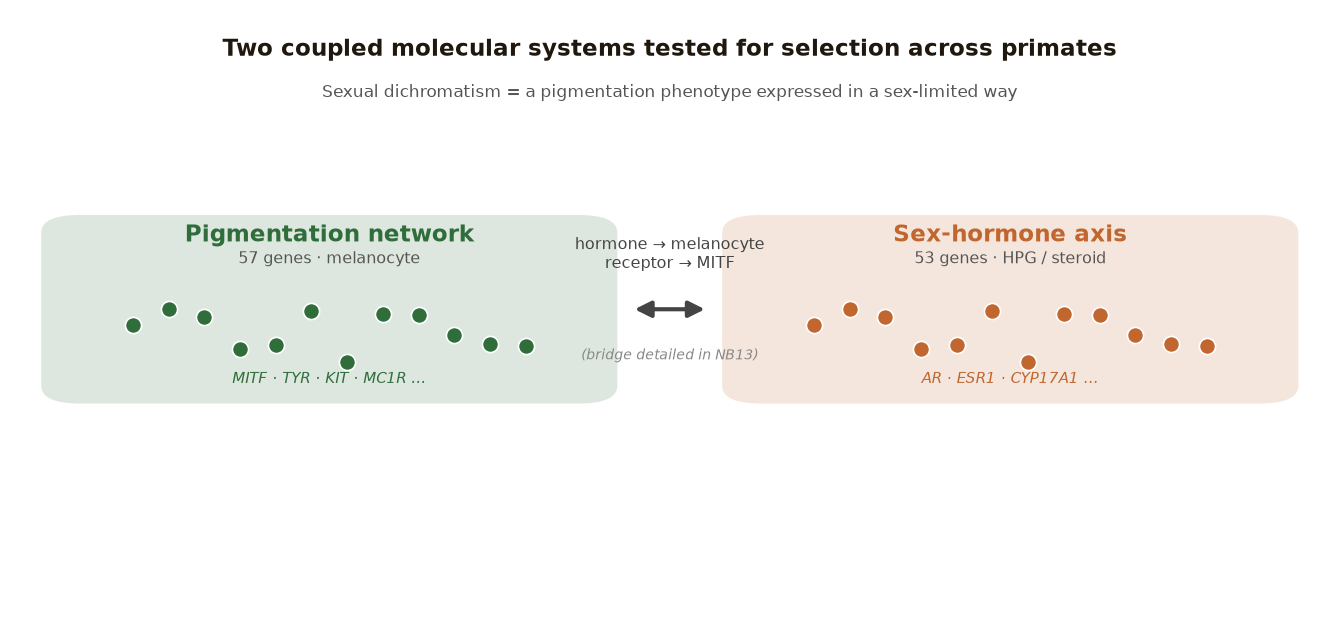

In [ ]:
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({"font.size":9,"axes.titlesize":10,"axes.titleweight":"bold","svg.fonttype":"none","figure.dpi":150,"axes.edgecolor":"#444"})
os.makedirs("figures", exist_ok=True)
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(9,4.2)); ax.axis("off"); ax.set_xlim(0,10); ax.set_ylim(0,10)
def _cloud(cx,cy,color,label,sub,genes):
    ax.add_patch(FancyBboxPatch((cx-2.1,cy-1.5),4.2,3.0,boxstyle="round,pad=0.1,rounding_size=0.3",fc=color,ec="none",alpha=0.16))
    ax.text(cx,cy+1.15,label,ha="center",fontsize=11,fontweight="bold",color=color)
    ax.text(cx,cy+0.78,sub,ha="center",fontsize=7.5,color="#555")
    rng=np.random.default_rng(7)
    for gx in np.linspace(cx-1.5,cx+1.5,12):
        ax.scatter(gx,cy-0.4+rng.uniform(-0.5,0.5),s=60,color=color,edgecolor="white",lw=0.8,zorder=3)
    ax.text(cx,cy-1.25,genes,ha="center",fontsize=7,color=color,style="italic")
_cloud(2.4,5,"#2f6d3a","Pigmentation network",f"{n_pig} genes \u00b7 melanocyte","MITF \u00b7 TYR \u00b7 KIT \u00b7 MC1R \u2026")
_cloud(7.6,5,"#c0662e","Sex-hormone axis",f"{n_hor} genes \u00b7 HPG / steroid","AR \u00b7 ESR1 \u00b7 CYP17A1 \u2026")
ax.add_patch(FancyArrowPatch((4.7,5),(5.3,5),arrowstyle="<|-|>",mutation_scale=16,color="#444",lw=2))
ax.text(5,5.7,"hormone \u2192 melanocyte\nreceptor \u2192 MITF",ha="center",fontsize=7.5,color="#444")
ax.text(5,4.15,"(bridge detailed in NB13)",ha="center",fontsize=6.5,color="#888",style="italic")
ax.text(5,9.3,"Two coupled molecular systems tested for selection across primates",ha="center",fontsize=11,fontweight="bold",color="#20180f")
ax.text(5,8.6,"Sexual dichromatism = a pigmentation phenotype expressed in a sex-limited way",ha="center",fontsize=8,color="#555")
fig.tight_layout(); fig.savefig("figures/nb14_coupled_networks.png",dpi=150,bbox_inches="tight"); plt.show()


## 6 — Print every gene in the panel, by module and function

In [ ]:
pig_orig = SCAN_PANEL[SCAN_PANEL.set=="pigmentation"].merge(
    NET[["gene","omim_pigment","in_baxter","has_raghunath"]], on="gene", how="left")
print("=== PIGMENTATION MODULE (original core, %d) ===" % n_pig0)
for cat, sub in pig_orig.groupby("category"):
    print(f"  {cat} ({len(sub)}): " + ", ".join(sorted(sub.gene)))
print("\n=== PIGMENTATION MODULE (clean additions, %d) ===" % len(clean))
for grp, sub in clean.groupby("group"):
    print(f"  {grp} ({len(sub)}): " + ", ".join(sorted(sub.gene)))
print("\n=== SEX-HORMONE MODULE (%d) ===" % n_hor)
for cat, sub in HAX.groupby("axis_category"):
    print(f"  {cat} ({len(sub)}): " + ", ".join(sorted(sub.gene)))

=== PIGMENTATION MODULE (original core, 27) ===
  enzyme (3): DCT, TYR, TYRP1
  melanosome (2): MLANA, PMEL
  melanosome_transport (5): MFSD12, OCA2, SLC24A4, SLC24A5, SLC45A2
  receptor_signaling (8): ASIP, EDN3, EDNRB, KIT, KITLG, MC1R, MRAP2, POMC
  regulatory (1): HERC2
  transcription (8): BNC2, FOXD3, IRF4, LEF1, MITF, PAX3, SOX10, TFAP2A

=== PIGMENTATION MODULE (clean additions, 30) ===
  melanogenesis_regulation (14): CDC42, CDH2, CTNNB1, EGFR, EP300, HGF, HRAS, MAPK3, PPP3CA, RACK1, RAF1, SPTLC2, SRC, TRAF6
  melanosome_biogenesis (16): AP3B1, AP3D1, BLOC1S6, CTNS, GPR143, HPS1, HPS3, HPS4, HPS5, LYST, MYO5A, RAB27A, RAB5C, SLC17A5, SLC1A2, SLC44A4

=== SEX-HORMONE MODULE (53) ===
  androgen_axis (7): AKR1C3, AR, CYP17A1, HSD17B3, SRD5A1, SRD5A2, SRD5A3
  coactivator_corepressor_carrier (7): FKBP5, NCOA1, NCOA2, NCOA3, NCOR1, NCOR2, SHBG
  estrogen_axis (7): CYP19A1, ESR1, ESR2, GPER1, HSD17B1, STS, SULT1E1
  gnrh_signaling (2): GNA11, GNAQ
  hpg_axis (10): CGA, FSHB, FSHR, G

## Result

The panel is **computed above**, not asserted: hormone axis (53) + original pigmentation core (27) + the
orthology-clean melanosome/regulation additions (30) = **110 genes**, near-perfectly balanced between the two
modules. Genes failing the orthology screen are listed with their exact ortholog/paralog counts and excluded.
This is the gene set carried into the per-branch (aBSREL) and per-origin (RELAX) selection analyses.

The written expansion list for the cluster is `config/gene_panel_expansion_clean30.csv`; the internal
provenance table (which genes are additions, full flag detail) is `data/nb14_panel_justification.csv`.